In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print(mixed_precision.global_policy())

<DTypePolicy "mixed_float16">


In [ ]:
SELECTED_CLASSES = [
    "pizza", "hamburger", "french_fries", "ice_cream", "chocolate_cake",
    "sushi", "ramen", "fried_rice", "omelette", "pancakes",
    "hot_dog", "grilled_salmon", "caesar_salad", "donuts", "dumplings",
]
(train_data, test_data), ds_info = tfds.load(
    "food101",
    split=["train", "validation"],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)
class_names = ds_info.features["label"].names

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.8BAELE_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.8BAELE_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [ ]:
BATCH_SIZE = 32
IMG_SIZE = 224
AUTOTUNE = tf.data.AUTOTUNE
selected_ids = tf.constant(
    [class_names.index(name) for name in SELECTED_CLASSES],
    dtype=tf.int64
)
def filter_classes(image, label):
    return tf.reduce_any(tf.equal(label, selected_ids))
def preprocess_image(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, label
train_data = (
    train_data
    .filter(filter_classes)
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
test_data = (
    test_data
    .filter(filter_classes)
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(
        keys=selected_ids,
        values=tf.range(len(SELECTED_CLASSES), dtype=tf.int64)
    ),
    default_value=-1
)
def remap_label(image, label):
    label = table.lookup(label)
    return image, label
train_data = train_data.map(remap_label, num_parallel_calls=AUTOTUNE)
test_data = test_data.map(remap_label, num_parallel_calls=AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(
    len(SELECTED_CLASSES),
    activation="softmax",
    dtype=tf.float32
)(x)
model = tf.keras.Model(inputs, outputs)
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(1e-3),
    metrics=["accuracy"]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
early_stopping_1 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
reduce_lr_1 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=2, verbose=1
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras", save_best_only=True
)

In [ ]:
history_1 = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data,
    callbacks=[early_stopping_1, reduce_lr_1, checkpoint]
)

Epoch 1/5
    352/Unknown 152s 307ms/step - accuracy: 0.5812 - loss: 1.5036

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


352/352 ━━━━━━━━━━━━━━━━━━━━ 195s 429ms/step - accuracy: 0.7146 - loss: 1.0510 - val_accuracy: 0.8776 - val_loss: 0.4302 - learning_rate: 0.0010
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 134s 355ms/step - accuracy: 0.8141 - loss: 0.6294 - val_accuracy: 0.8901 - val_loss: 0.3594 - learning_rate: 0.0010
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 381ms/step - accuracy: 0.8326 - loss: 0.5589 - val_accuracy: 0.8976 - val_loss: 0.3308 - learning_rate: 0.0010
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 132s 349ms/step - accuracy: 0.8441 - loss: 0.5230 - val_accuracy: 0.8957 - val_loss: 0.3140 - learning_rate: 0.0010
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 132s 353ms/step - accuracy: 0.8513 - loss: 0.4977 - val_accuracy: 0.9067 - val_loss: 0.2988 - learning_rate: 0.0010


In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(1e-5),
    metrics=["accuracy"]
)
early_stopping_2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
reduce_lr_2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=2, verbose=1
)
history_2 = model.fit(
    train_data,
    epochs=20,
    validation_data=test_data,
    callbacks=[early_stopping_2, reduce_lr_2, checkpoint]
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 177s 396ms/step - accuracy: 0.7363 - loss: 0.9188 - val_accuracy: 0.8709 - val_loss: 0.4337 - learning_rate: 1.0000e-05
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 143s 385ms/step - accuracy: 0.7915 - loss: 0.7329 - val_accuracy: 0.8859 - val_loss: 0.3878 - learning_rate: 1.0000e-05
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 195s 360ms/step - accuracy: 0.8122 - loss: 0.6569 - val_accuracy: 0.8912 - val_loss: 0.3577 - learning_rate: 1.0000e-05
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 362ms/step - accuracy: 0.8229 - loss: 0.6134 - val_accuracy: 0.8965 - val_loss: 0.3365 - learning_rate: 1.0000e-05
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 134s 353ms/step - accuracy: 0.8321 - loss: 0.5764 - val_accuracy: 0.9005 - val_loss: 0.3223 - learning_rate: 1.0000e-05
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 135s 359ms/step - accuracy: 0.8385 - loss: 0.5497 - val_accuracy: 0.9013 - val_loss: 0.3126 - learning_rate: 1.0000e-05
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
results = model.evaluate(test_data)
print(results)

def predict_image(model, image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    pred = model.predict(tf.expand_dims(image, axis=0))
    pred_class = SELECTED_CLASSES[np.argmax(pred)]
    plt.imshow(tf.cast(image/255., tf.float32))
    plt.title(pred_class)
    plt.axis(False)
    print(pred_class)

118/118 ━━━━━━━━━━━━━━━━━━━━ 31s 262ms/step - accuracy: 0.9227 - loss: 0.2508
[0.2508212625980377, 0.9226666688919067]


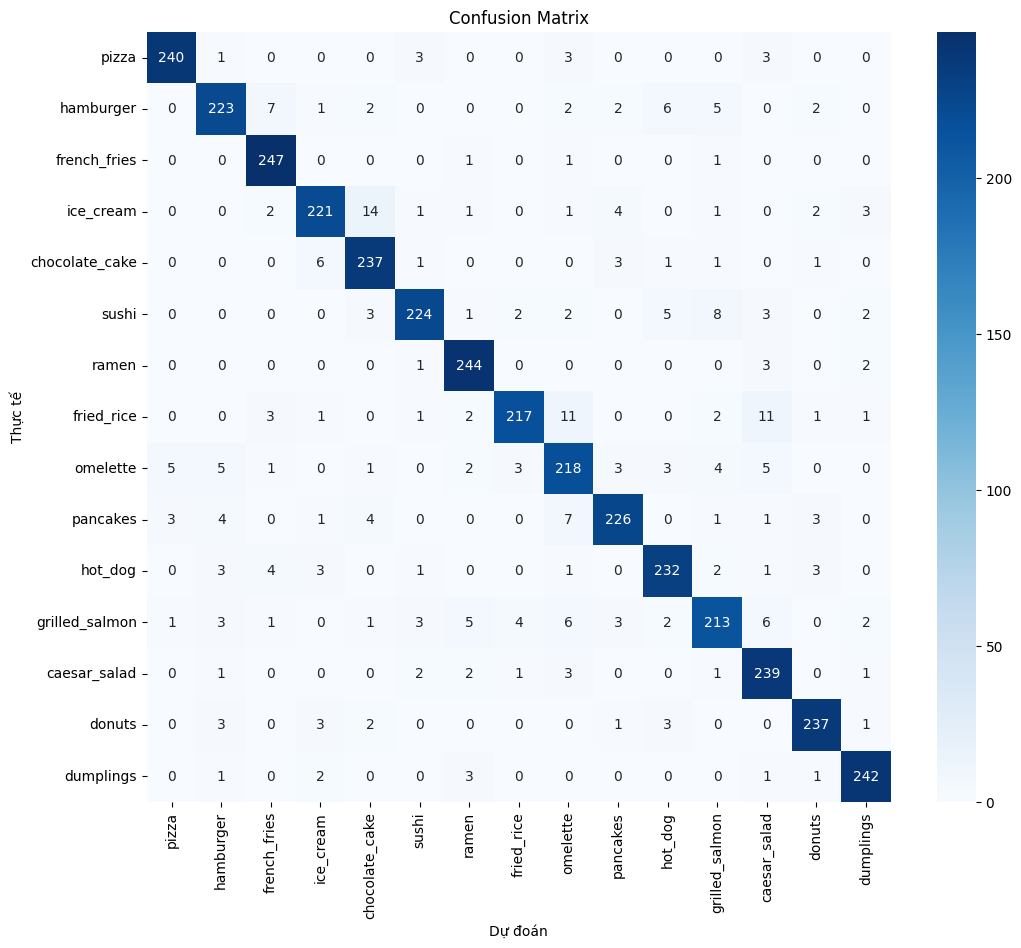

Classification Report:
                precision    recall  f1-score   support

         pizza     0.9639    0.9600    0.9619       250
     hamburger     0.9139    0.8920    0.9028       250
  french_fries     0.9321    0.9880    0.9592       250
     ice_cream     0.9286    0.8840    0.9057       250
chocolate_cake     0.8977    0.9480    0.9222       250
         sushi     0.9451    0.8960    0.9199       250
         ramen     0.9349    0.9760    0.9550       250
    fried_rice     0.9559    0.8680    0.9099       250
      omelette     0.8549    0.8720    0.8634       250
      pancakes     0.9339    0.9040    0.9187       250
       hot_dog     0.9206    0.9280    0.9243       250
grilled_salmon     0.8912    0.8520    0.8712       250
  caesar_salad     0.8755    0.9560    0.9140       250
        donuts     0.9480    0.9480    0.9480       250
     dumplings     0.9528    0.9680    0.9603       250

      accuracy                         0.9227      3750
     macro avg     0.92

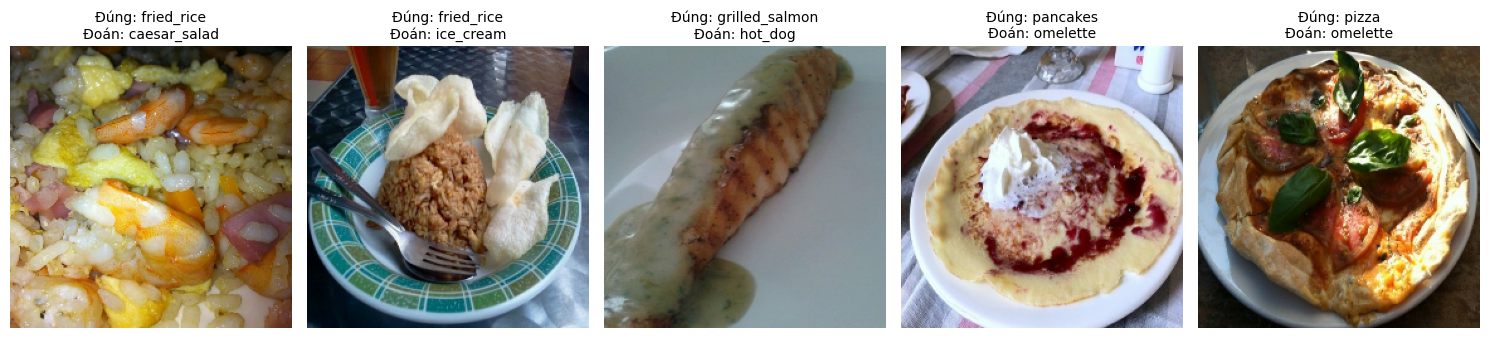

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
y_true = []
y_pred = []
images_list = []
for images, labels in test_data:
    preds = model.predict(images, verbose=0)
    preds_idx = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds_idx)
    images_list.append(images.numpy())
y_true = np.array(y_true)
y_pred = np.array(y_pred)
all_images = np.concatenate(images_list, axis=0)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES, cmap='Blues')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix')
plt.show()
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=SELECTED_CLASSES, digits=4))
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"\nSố ảnh bị sai: {len(misclassified_idx)} / {len(y_true)}")
num_display = min(5, len(misclassified_idx))
if num_display > 0:
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(misclassified_idx[:num_display]):
        plt.subplot(1, num_display, i+1)
        plt.imshow(all_images[idx].astype(np.uint8))
        true_name = SELECTED_CLASSES[y_true[idx]]
        pred_name = SELECTED_CLASSES[y_pred[idx]]
        plt.title(f"Đúng: {true_name}\nĐoán: {pred_name}", fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()